#**Objetivos**

* Hacer un modelo que prediga la posible salida de clientes.
* Obtener un Pipeline de procesamiento de datos.
* Obtener el modelo más adecuado al problema.

##**Pasos**
* Revisar la calidad de la data (Tipos de datos, valores nulos, duplicados y valores negativos que no correspondan)
* Hacer un análisis exploratorio univariado y bivariado, además de incluir métodos de aprendizaje no supervisado como PCA y TNSE.
* Construir pipelines de Procesamiento basado en el análisis exploratorio de datos.
* Probar distintos modelos de clasificación lineales y no lineales.
* Realizar una búsqueda de hiperparámetros inicial para detectar el modelo más adecuado al problema.






#**Librerías**

In [26]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

#**Cargar el Dataset**

In [10]:
df = pd.read_csv('Telco-Customer-Churn.csv')

#**Exploración inicial del Dataset**

In [11]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


##**Valores duplicados**

In [12]:
duplicados = df.duplicated()
duplicados[duplicados > 0]

,0


##**Eliminar la Columna CustomerID**

In [13]:
df = df.drop(columns='customerID')

##**Tamaño del Dataset**

In [14]:
df.shape

(7043, 20)

##**Valores nulos**

In [15]:
nulos = df.isnull().sum()
nulos[nulos>0]

,0


#**Tipos de datos**

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


##**Cambiar el tipo de dato de la columna TotalCharges**
Esto genera un error, por lo que luego se procederá averiguar por qué ocurre este error.

In [17]:
# df['TotalCharges'] = df['TotalCharges'].astype('float64')

##**Revisión de la columna TotalCharges**

In [18]:
regex_numeros = r'^\d+(?:\.\d+)?$'

solo_numeros = df['TotalCharges'].str.contains(regex_numeros, na = False).sum()
print(f'Total de filas del dataset: {df.shape[0]} \n Total de valores numéricos en columna Total Charges {solo_numeros}')

Total de filas del dataset: 7043 
 Total de valores numéricos en columna Total Charges 7032


##**Revisión de filas que no contienen valores numéricos**
Las filas que no contienen números en TotalCharges, no tienen ningún valor numérico, probablemente es un '', considerando las columnas tenure y Contract, probablemente son clientes que recién firmaron un contrato, por lo que lo más correcto sería reemplazar esos valores por 0

In [19]:
mascara_filas_sin_num = df['TotalCharges'].str.contains(regex_numeros, na = False)
filas_sin_numeros = df[~mascara_filas_sin_num]
filas_sin_numeros[['tenure','Contract','MonthlyCharges','TotalCharges']]

,tenure,Contract,MonthlyCharges,TotalCharges
488,0,Two year,52.55,
753,0,Two year,20.25,
936,0,Two year,80.85,
1082,0,Two year,25.75,
1340,0,Two year,56.05,
3331,0,Two year,19.85,
3826,0,Two year,25.35,
4380,0,Two year,20.00,
5218,0,One year,19.70,
6670,0,Two year,73.35,


##**Reemplazar valores faltantes por 0**

In [20]:
df['TotalCharges'] = df['TotalCharges'].str.replace(r'^\s*$', '0', regex=True)

df['TotalCharges'] = df['TotalCharges'].astype('float64')

##**Resumen estadístico de las variables numéricas**
* SeniorCitizen es una variable discreta ya que solo toma valores de números entre 0 y 1

In [21]:
df.select_dtypes(include=['number']).describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


#**Conclusiones de la exploración inicial**
* CustomerID no se utilizará para el modelo ya que es una variable que solo sirve para identificar al cliente.
* No hay valores duplicados.
* Tenure y SeniorCitizen son variables discretas.
* TotalCharges es un object o String en el Dataset y debería ser un Float.
* Habían valores nulos, pero no podían identificarse inicialmente ya que estaban como un string ' '.
* No hay presencia de valores negativos donde no corresponden.

#**Análisis exploratorio de Datos**

#**Análisis univariado**


##**Exploración de las variables cuantitativas**
Aquí analizaremos 2 gráficos de **distribución**:
* **Boxplot** para encontrar valores **atítpicos**, además de ver el rango de valores entre los que se encuentra la variable.
* **Histograma** para ver la forma que tiene la distribución.

In [47]:
df_cuantitativas = df.select_dtypes('number').drop(columns = 'SeniorCitizen').columns
colores_num = ['#4682B4', '#5F9EA0', '#CD853F']

##**Revisar Outliers en cada variable cuantitativa**
* No se observan Outliers

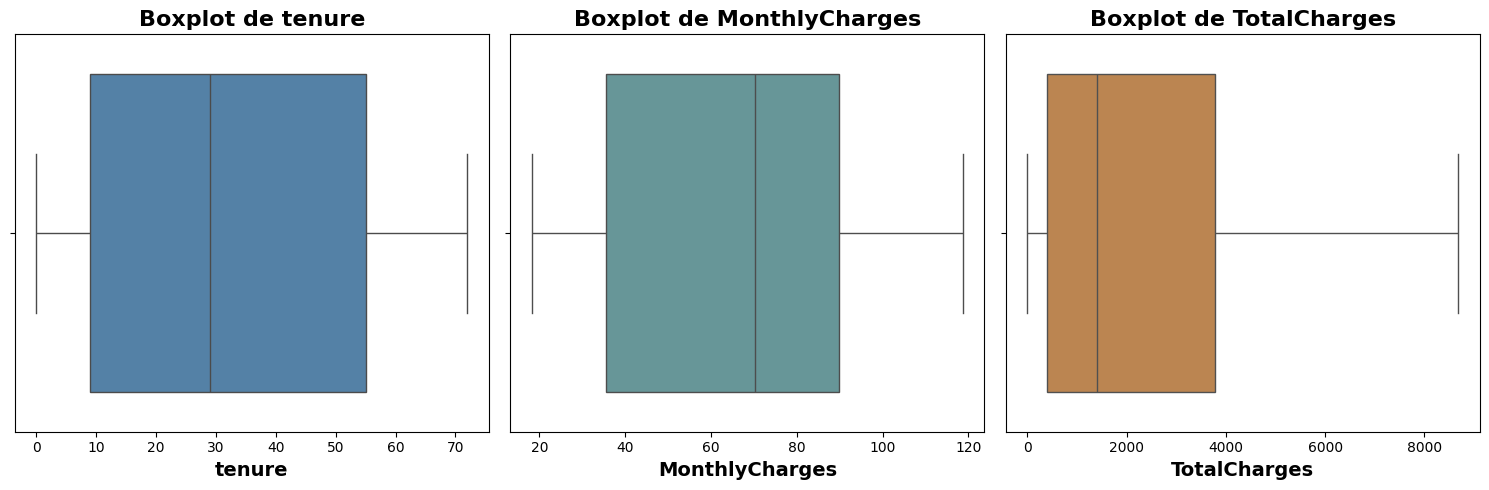

In [49]:
fig, ax = plt.subplots(1,3, figsize=(15,5))

for j, col in enumerate(df_cuantitativas):
  ax[j] = sns.boxplot(df, x=col, ax=ax[j], color = colores_num[j])
  ax[j].set_title(f'Boxplot de {col}', fontsize = 16, fontweight = 'bold')
  ax[j].set_xlabel(f'{col}', fontsize = 14, fontweight = 'bold')

plt.tight_layout()
plt.show()

##**Distribución de variables cuantitativas**
* La mayor cantidad de clientes llevan poco tiempo con el servicio, por eso se ve que en el gráfico de TotalCharges está muy cercano a 0.
* La variable TotalCharges podría hacerse una transformación con logaritmo +1, ya que se ve que tiene una cola a la derecha y para modelos lineales podría obtenerse mejores resultados.

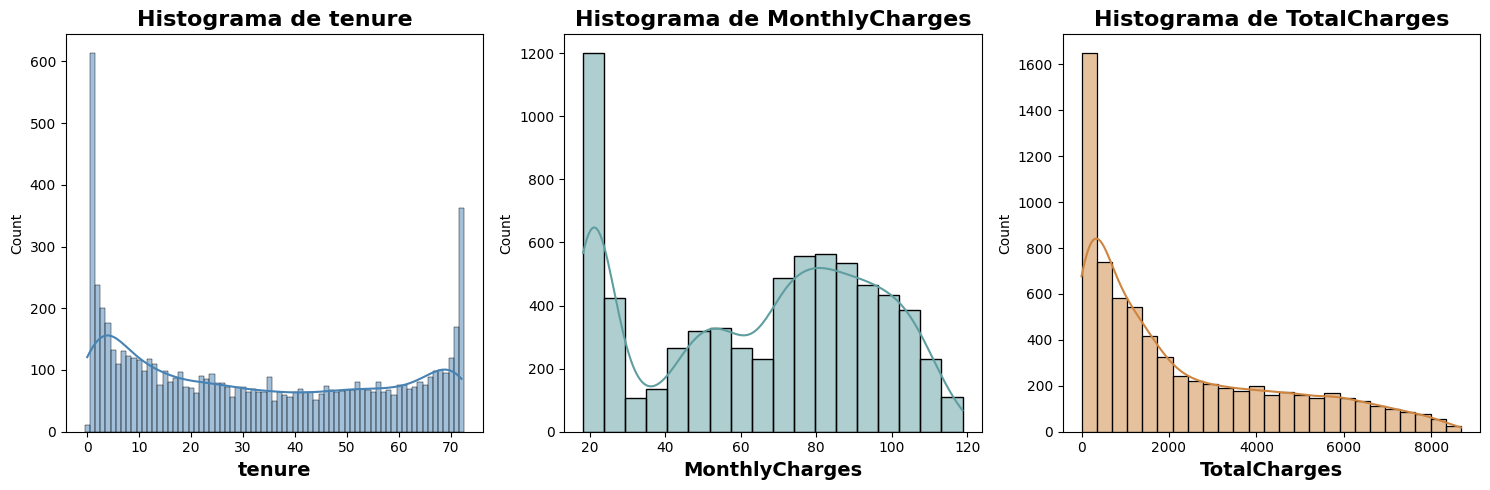

In [55]:
fig, ax = plt.subplots(1, 3, figsize = (15, 5))

for j, col in enumerate(df_cuantitativas):
  if col == 'tenure':
    ax[j] = sns.histplot(df, x= col, kde = True, color= colores_num[j], ax = ax[j], discrete = True)
  else:
    ax[j] = sns.histplot(df, x= col, kde = True, color= colores_num[j], ax = ax[j])
  ax[j].set_xlabel(f'{col}',fontsize = 14, fontweight = 'bold')
  ax[j].set_title(f'Histograma de {col}', fontsize = 16, fontweight = 'bold')

plt.tight_layout()
plt.show()

##**Análisis SeniorCitizen (Variable Discreta)**
* Hay una gran diferencia entre las personas que no tienen ciudadanía, por lo que si podría ser una buena variable predictora.

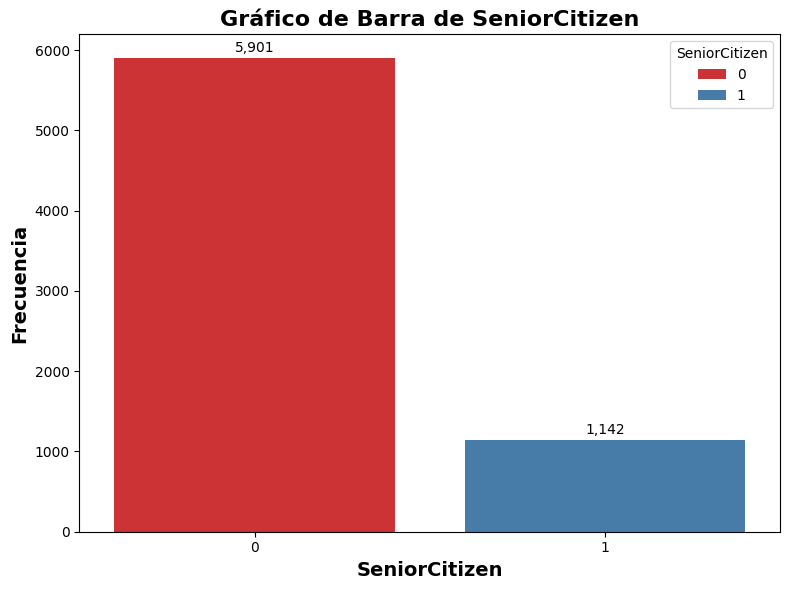

In [93]:
fig, ax = plt.subplots(figsize = (8,6))

ax = sns.countplot(df, x='SeniorCitizen', hue='SeniorCitizen', palette='Set1')
ax.set_xlabel('SeniorCitizen', fontsize = 14, fontweight = 'bold')
ax.set_ylabel('Frecuencia', fontsize = 14, fontweight = 'bold')
ax.set_title('Gráfico de Barra de SeniorCitizen', fontsize = 16, fontweight = 'bold')
for container in ax.containers:
  ax.bar_label(container,padding = 2, fmt='{:,.0f}')

plt.tight_layout()
plt.show()

##**Análisis Univariado de variables categóricas**

In [61]:
lista_categoricas = df.select_dtypes('object').drop(columns = 'Churn').columns
lista_categoricas

Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='object')